# 04 · Segments & recommendations

**Question answered.** (5) Which segments retain best — UK vs international, first-order value tier, Q4 vs other
cohorts? — followed by recommendations with quantified, clearly-labelled *illustrative* impact.

Every segment comparison uses **repeat-within-90-days on true-new customers in fully observed cohorts**, so each
customer had the same opportunity to return.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Markdown, display
from retention import config, core, plots

%matplotlib inline
pd.set_option("display.max_columns", 30, "display.width", 160, "display.float_format", "{:,.4f}".format)
WINDOW = 90   # repeat-purchase window (days) for the headline metric

In [2]:
lines = pd.read_parquet(config.LINES_PARQUET)
bounds = core.period_bounds(lines)
orders = core.build_orders(lines)
customers = core.build_customers(orders, bounds)
print(f"{len(lines):,} line items -> {len(orders):,} orders from {len(customers):,} customers")
print({k: str(v) for k, v in bounds.items()})

802,632 line items -> 36,594 orders from 5,852 customers
{'data_end': '2011-12-09 12:50:00', 'first_month': '2009-12', 'last_complete_month': '2011-11', 'last_month': '2011-12'}


## 1. Segment tables

In [3]:
key = f"repeat_{WINDOW}d"
segments = core.segments_long(customers, bounds, WINDOW)
headline = core.headline_metrics(orders, customers, bounds, WINDOW)
segments.style.format({"n": "{:,.0f}", key: "{:.1%}", "avg_orders": "{:.2f}",
                       "median_first_order_value": "£{:,.0f}", "revenue_per_customer": "£{:,.0f}"}).hide(axis="index")

segment_type,segment_value,n,repeat_90d,avg_orders,median_first_order_value,revenue_per_customer,small_sample
Region,International,402,44.0%,4.48,£407,"£3,092",False
Region,UK,"3,871",43.2%,4.78,£284,"£1,875",False
FirstOrderTier,Low,"1,464",34.8%,3.72,£135,"£1,009",False
FirstOrderTier,Mid,"1,396",44.3%,4.67,£295,"£1,427",False
FirstOrderTier,High,"1,413",51.0%,5.89,£572,"£3,562",False
IsQ4Cohort,False,"3,496",45.0%,5.08,£292,"£2,156",False
IsQ4Cohort,True,777,35.5%,3.24,£295,"£1,242",False
CohortYear,2010,"3,364",43.2%,5.20,£294,"£2,158",False
CohortYear,2011,909,43.6%,3.10,£285,"£1,369",False


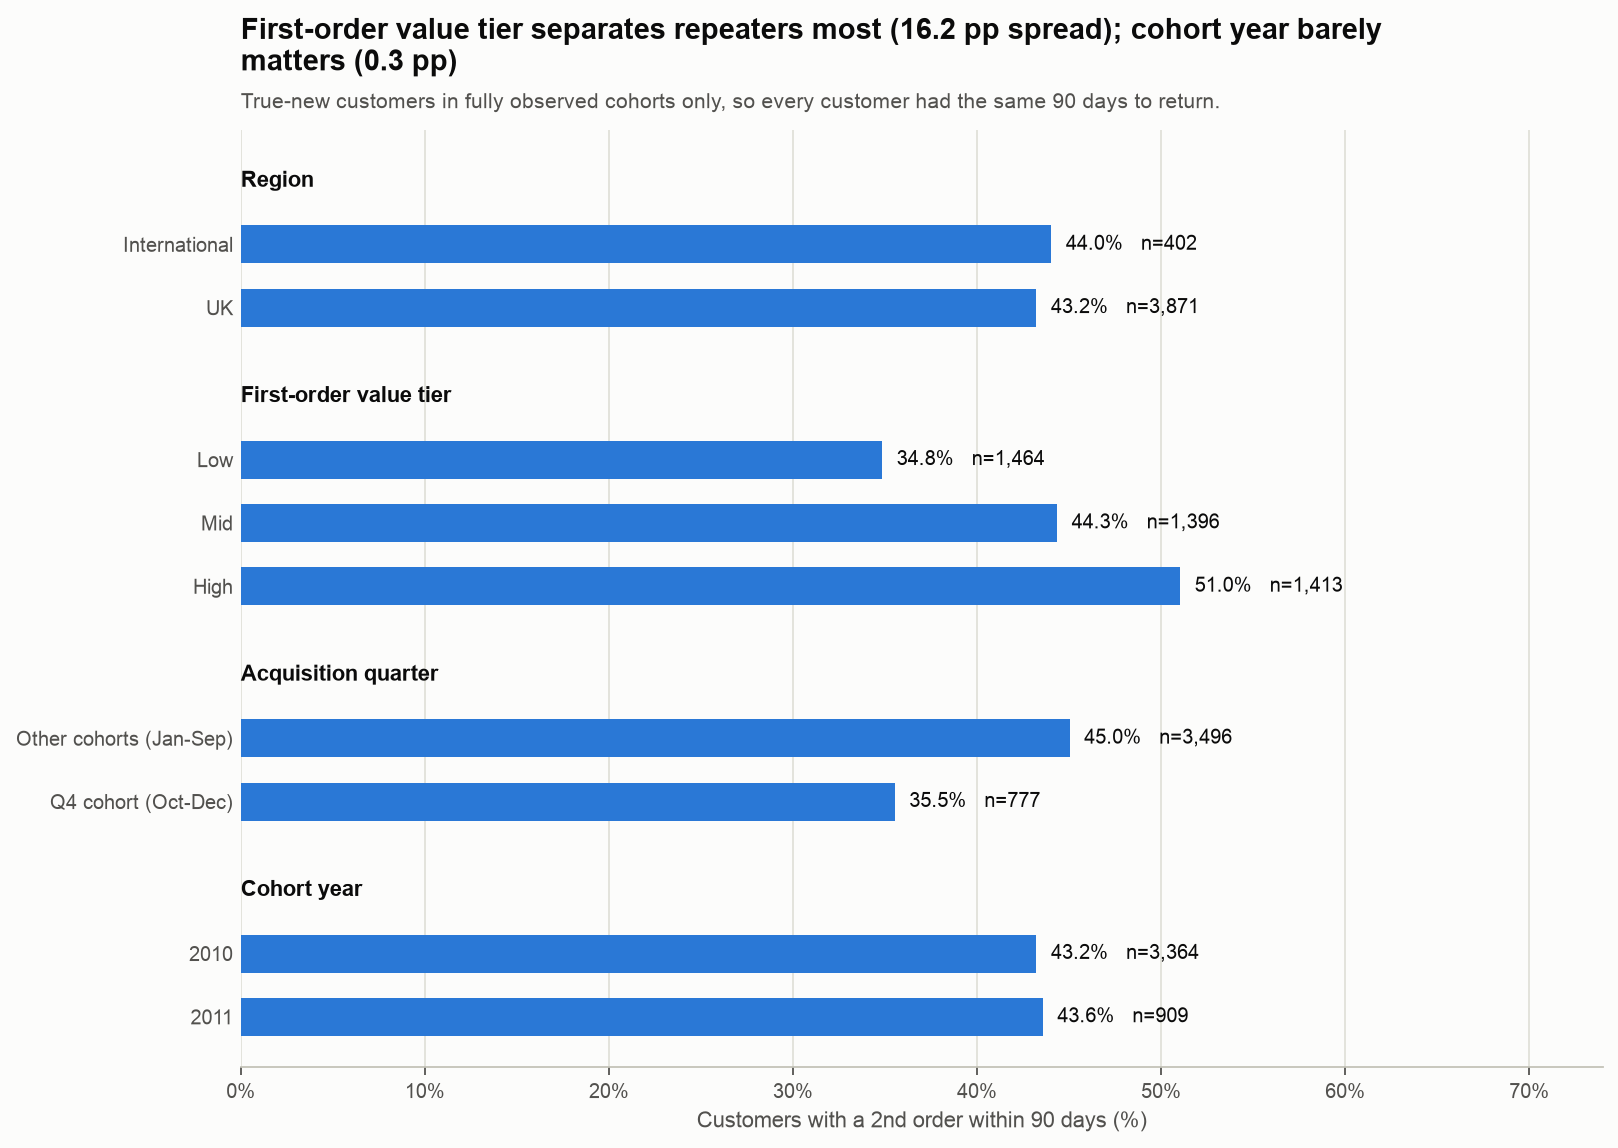

In [4]:
plots.segment_repeat_rates(segments, WINDOW)

### Are the gaps real?

Each gap is reported in percentage points with a normal-approximation 95% confidence interval. If the interval spans zero the difference is small relative to the sample sizes and is **not** treated as a finding.

In [5]:
gaps = pd.DataFrame(headline["segment_gaps"]).T
gaps["verdict"] = gaps["distinguishable"].map({True: "real difference", False: "no meaningful difference"})
display(gaps[["a", "b", "n_a", "n_b", "diff_pp", "ci_low_pp", "ci_high_pp", "verdict"]]
        .style.format({"diff_pp": "{:+.1f}", "ci_low_pp": "{:+.1f}", "ci_high_pp": "{:+.1f}"}))
small = segments[segments["small_sample"]]
print("small-sample segments (n < 100):", "none" if small.empty else small[["segment_type", "segment_value", "n"]].to_dict("records"))

,a,b,n_a,n_b,diff_pp,ci_low_pp,ci_high_pp,verdict
Region,UK,International,3871,402,-0.8,-5.9,+4.3,no meaningful difference
FirstOrderTier,High,Low,1413,1464,+16.2,+12.6,+19.8,real difference
IsQ4Cohort,True,False,777,3496,-9.5,-13.2,-5.8,real difference
CohortYear,2011,2010,909,3364,+0.3,-3.3,+4.0,no meaningful difference


small-sample segments (n < 100): none


In [6]:
g, s = headline["segment_gaps"], headline["segments"]
def line(seg):
    x = g[seg]
    return (f"{s[seg][x['a']][key]:.1%} (n={x['n_a']:,}) vs {s[seg][x['b']][key]:.1%} (n={x['n_b']:,}): "
            f"{x['diff_pp']:+.1f} pp, 95% CI {x['ci_low_pp']:+.1f} to {x['ci_high_pp']:+.1f}")
tiers = core.tier_bounds(customers)
display(Markdown(
    f"- **UK vs International** - {line('Region')}. The interval comfortably spans zero: **there is no meaningful "
    f"difference** in repeat rate by region, and no story should be told about one. (International customers do "
    f"spend more per head - £{s['Region']['International']['revenue_per_customer']:,.0f} vs "
    f"£{s['Region']['UK']['revenue_per_customer']:,.0f} mean revenue - but that is order size, not loyalty.)\n"
    f"- **First-order value tier (High vs Low)** - {line('FirstOrderTier')}. A clear, monotonic gradient: Low "
    f"(up to £{tiers.loc['Low', 'max']:,.0f}) {s['FirstOrderTier']['Low'][key]:.1%}, Mid "
    f"{s['FirstOrderTier']['Mid'][key]:.1%}, High (from £{tiers.loc['High', 'min']:,.0f}) "
    f"{s['FirstOrderTier']['High'][key]:.1%}.\n"
    f"- **Q4 cohorts vs the rest** - {line('IsQ4Cohort')}. Customers first acquired in October-December come back "
    f"less: seasonal gift buyers.\n"
    f"- **Cohort year ({g['CohortYear']['a']} vs {g['CohortYear']['b']})** - {line('CohortYear')}. **No meaningful "
    f"difference**: newer cohorts are neither better nor worse than older ones once compared like-for-like."))

- **UK vs International** - 43.2% (n=3,871) vs 44.0% (n=402): -0.8 pp, 95% CI -5.9 to +4.3. The interval comfortably spans zero: **there is no meaningful difference** in repeat rate by region, and no story should be told about one. (International customers do spend more per head - £3,092 vs £1,875 mean revenue - but that is order size, not loyalty.)
- **First-order value tier (High vs Low)** - 51.0% (n=1,413) vs 34.8% (n=1,464): +16.2 pp, 95% CI +12.6 to +19.8. A clear, monotonic gradient: Low (up to £208) 34.8%, Mid 44.3%, High (from £374) 51.0%.
- **Q4 cohorts vs the rest** - 35.5% (n=777) vs 45.0% (n=3,496): -9.5 pp, 95% CI -13.2 to -5.8. Customers first acquired in October-December come back less: seasonal gift buyers.
- **Cohort year (2011 vs 2010)** - 43.6% (n=909) vs 43.2% (n=3,364): +0.3 pp, 95% CI -3.3 to +4.0. **No meaningful difference**: newer cohorts are neither better nor worse than older ones once compared like-for-like.

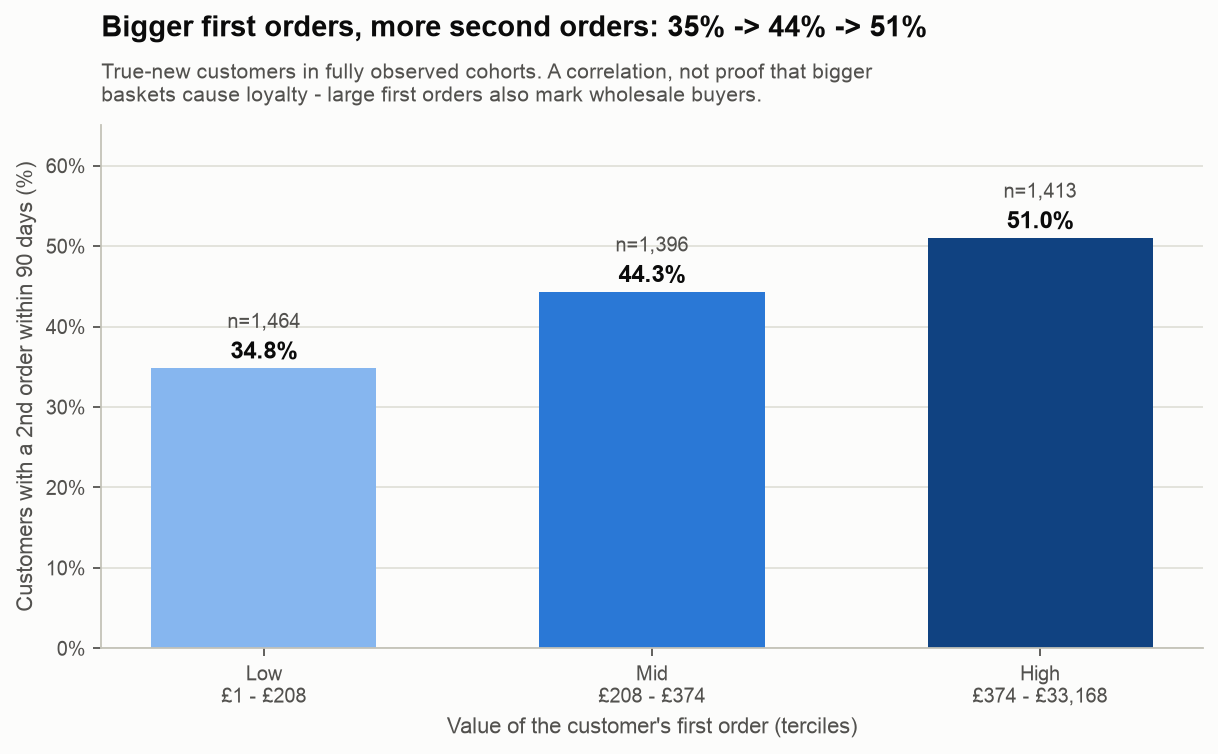

In [7]:
plots.first_order_tier(segments, tiers, WINDOW)

## 2. Segment retention curves

`retention_matrix(..., customer_ids=...)` recomputes the matrix for a subset while keeping every customer in their original cohort.

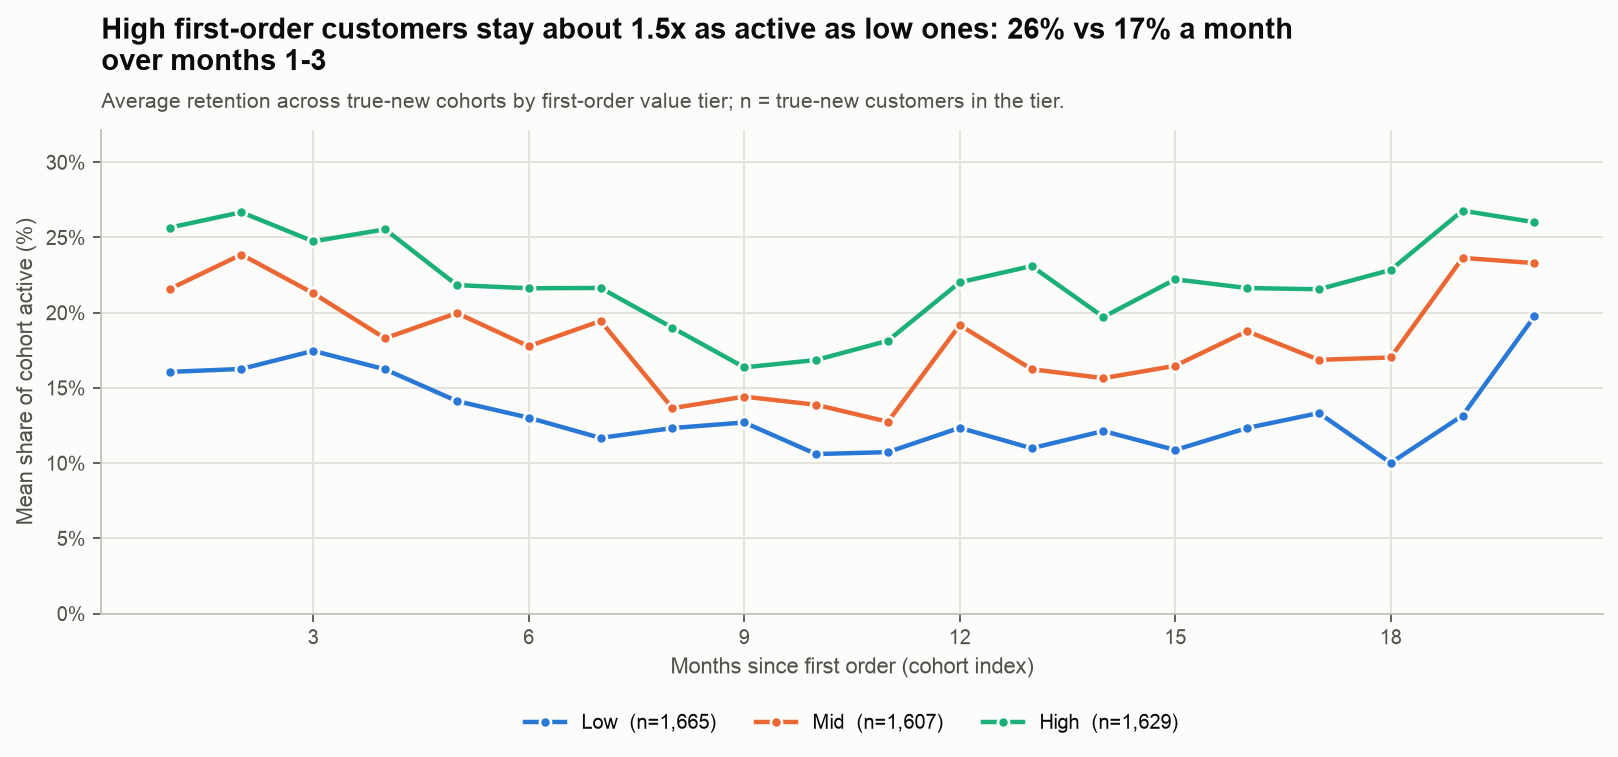

In [8]:
def segment_curves(column):
    out = {}
    for value in sorted(customers[column].dropna().unique(), key=str):
        ids = customers.index[customers[column] == value]
        R = core.retention_matrix(orders, bounds, ids)
        n_true_new = int(customers.loc[ids, "IsTrueNew"].sum())
        out[plots.t.segment_value_label(column, value) + f"  (n={n_true_new:,})"] = core.average_retention_curve(
            R["pct"], first_month=bounds["first_month"])
    return out

tier_curves = segment_curves("FirstOrderTier")
tier_curves = {k: tier_curves[k] for name in ("Low", "Mid", "High") for k in tier_curves if k.startswith(name)}
m3 = {k.split("  ")[0]: v.loc[1:3].mean() for k, v in tier_curves.items()}
plots.segment_retention_curves(
    tier_curves,
    f"High first-order customers stay about {m3['High'] / m3['Low']:.1f}x as active as low ones: "
    f"{m3['High']:.0%} vs {m3['Low']:.0%} a month over months 1-3",
    "Average retention across true-new cohorts by first-order value tier; n = true-new customers in the tier.")

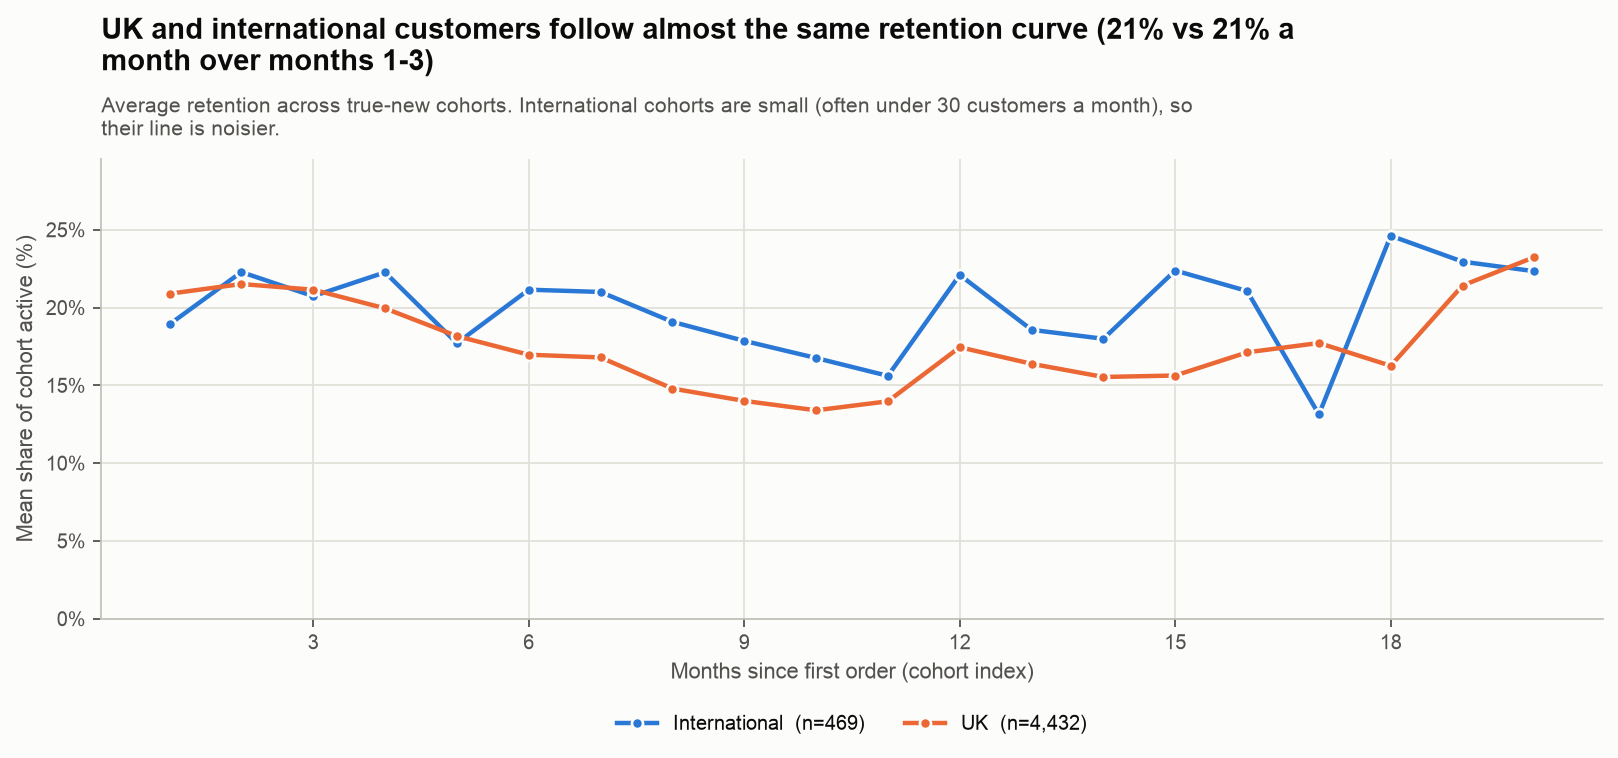

In [9]:
region_curves = segment_curves("Region")
m3 = {k.split("  ")[0]: v.loc[1:3].mean() for k, v in region_curves.items()}
plots.segment_retention_curves(
    region_curves,
    f"UK and international customers follow almost the same retention curve "
    f"({m3['UK']:.0%} vs {m3['International']:.0%} a month over months 1-3)",
    "Average retention across true-new cohorts. International cohorts are small (often under 30 customers a "
    "month), so their line is noisier.")

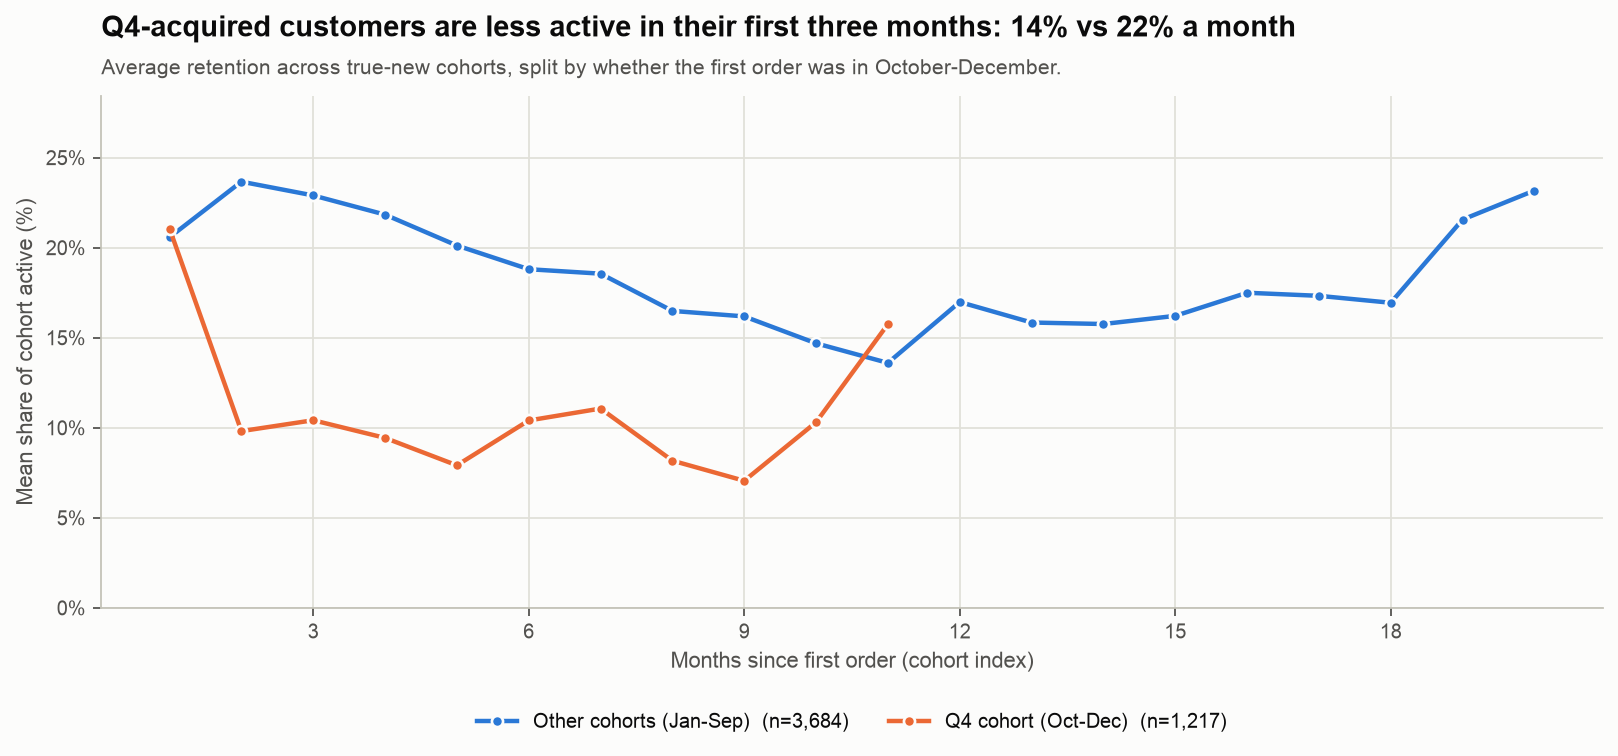

In [10]:
q4_curves = segment_curves("IsQ4Cohort")
m3 = {k.split("  ")[0]: v.loc[1:3].mean() for k, v in q4_curves.items()}
names = list(m3)
plots.segment_retention_curves(
    q4_curves,
    f"Q4-acquired customers are less active in their first three months: "
    f"{m3[[n for n in names if n.startswith('Q4')][0]]:.0%} vs {m3[[n for n in names if n.startswith('Other')][0]]:.0%} a month",
    "Average retention across true-new cohorts, split by whether the first order was in October-December.")

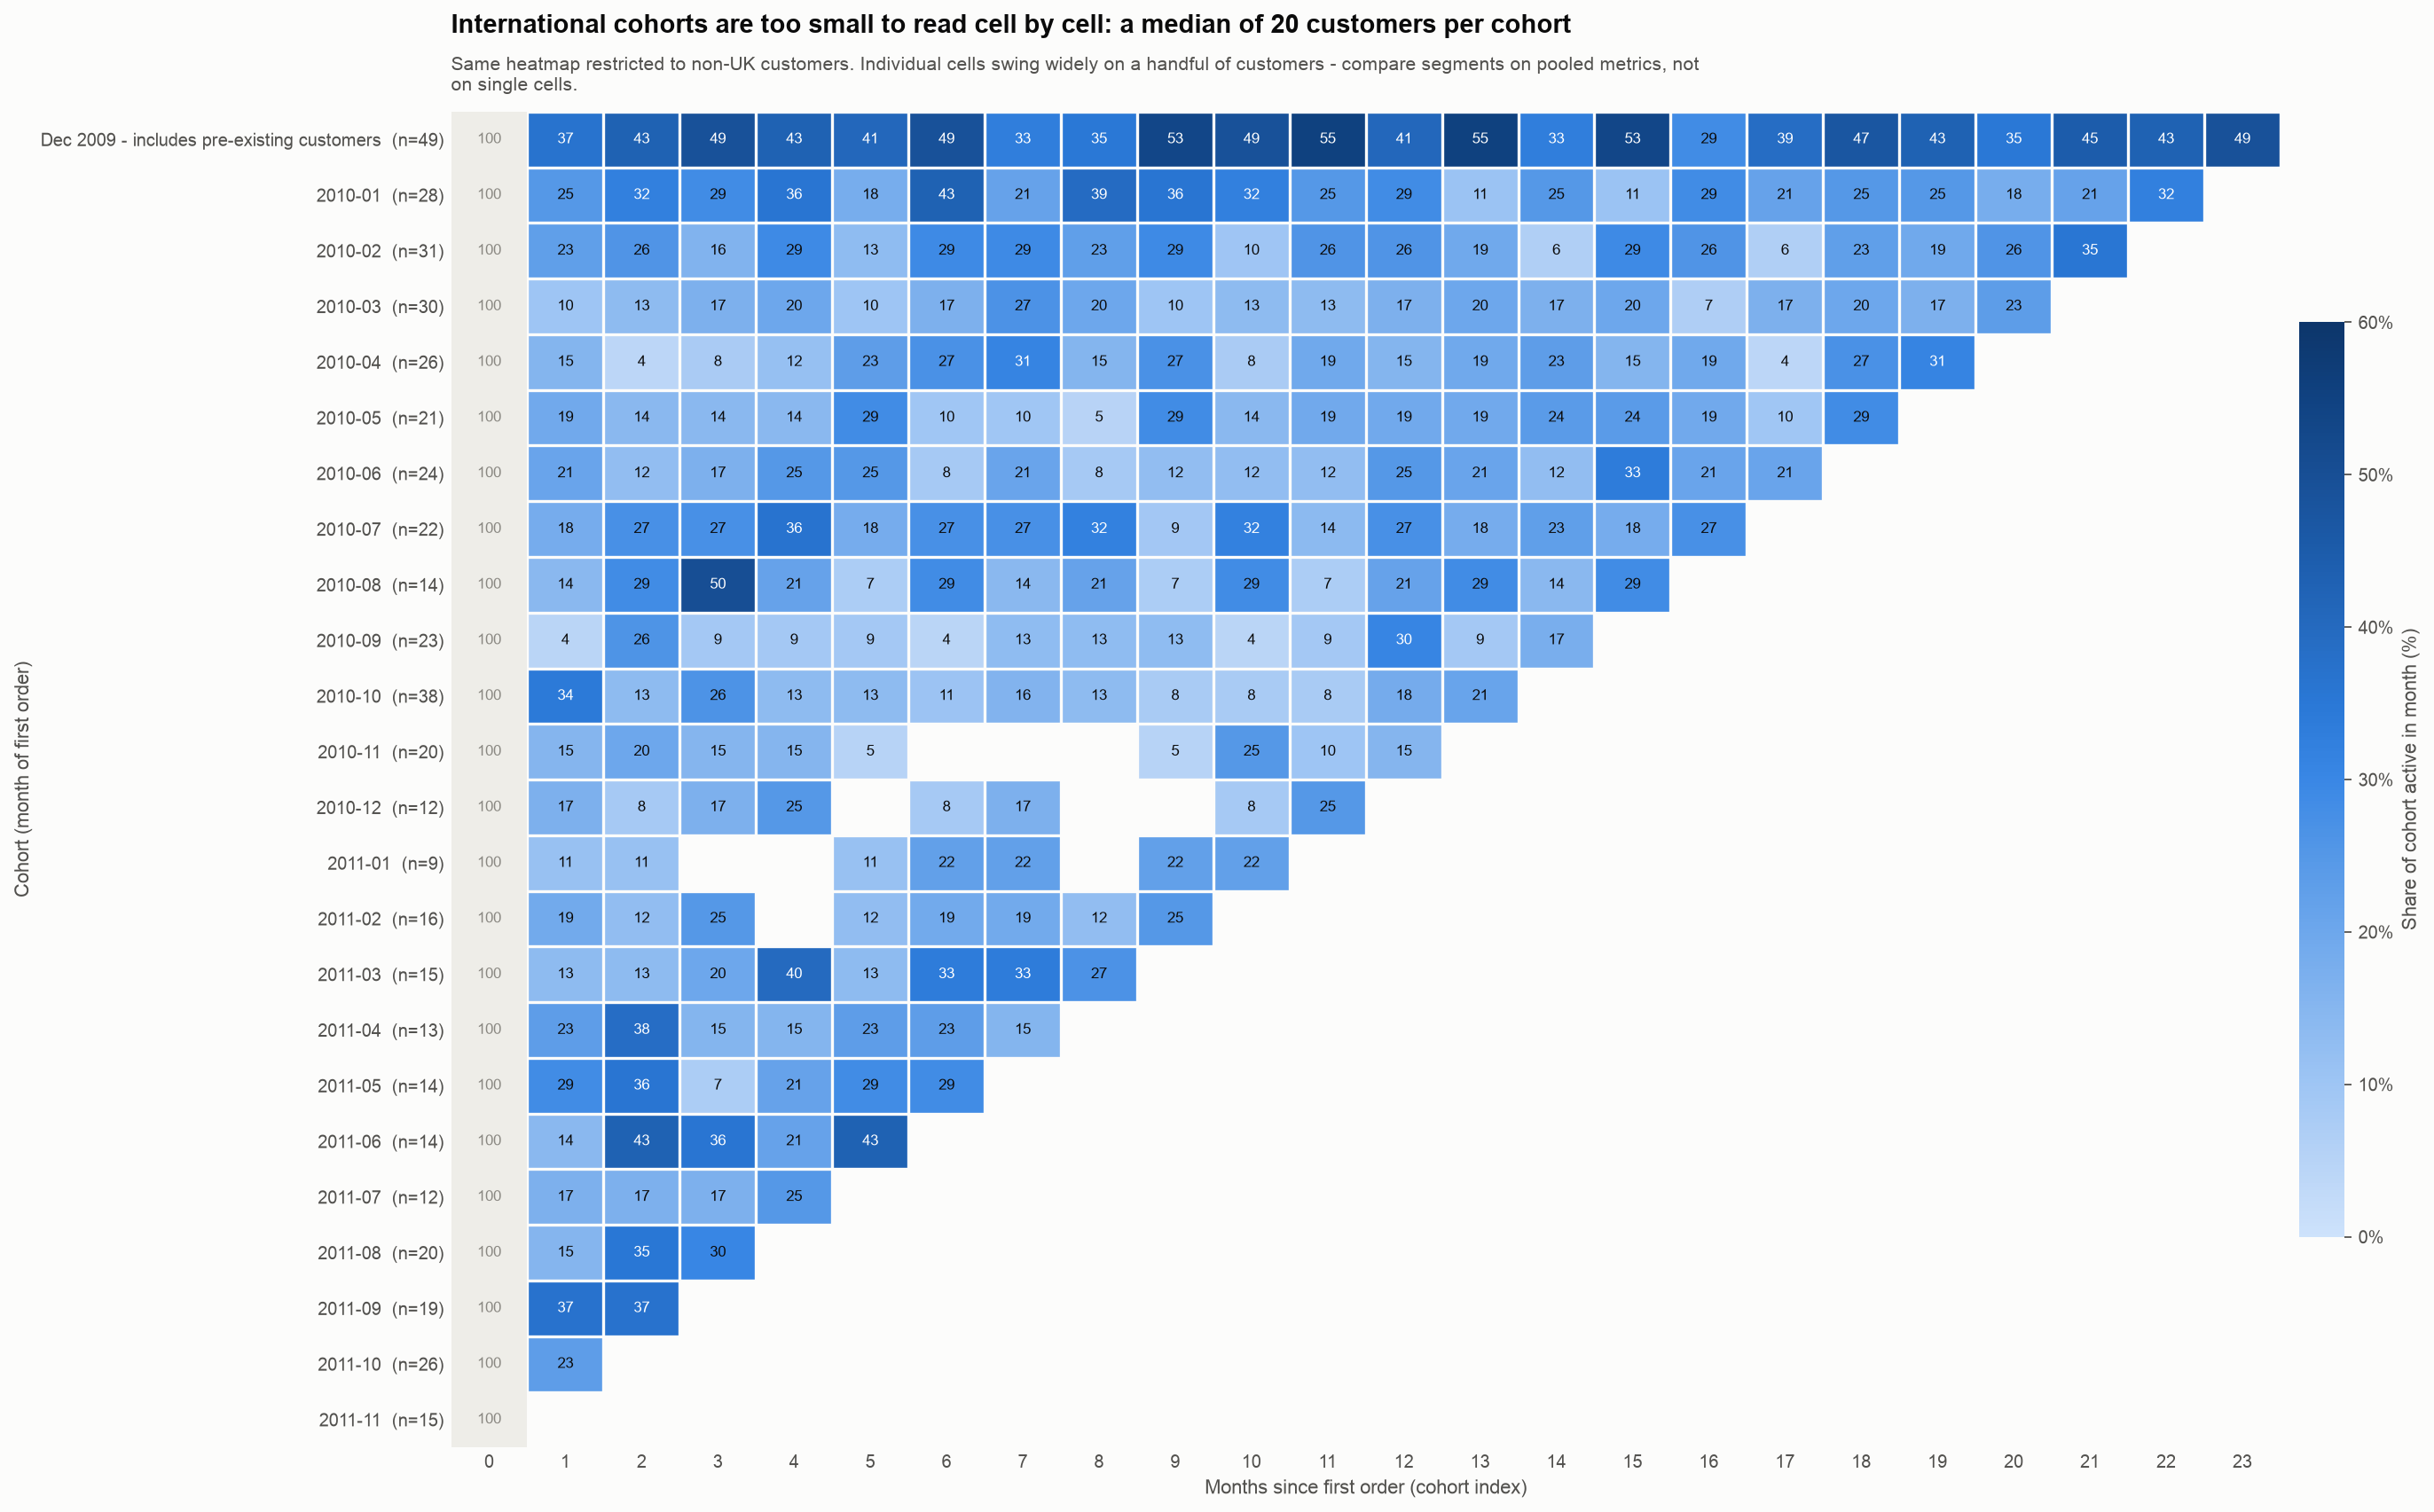

In [11]:
R_intl = core.retention_matrix(orders, bounds, customers.index[customers["Region"] == "International"])
plots.retention_heatmap(
    R_intl["pct"], R_intl["sizes"], bounds["first_month"],
    title=f"International cohorts are too small to read cell by cell: a median of "
          f"{R_intl['sizes'].median():.0f} customers per cohort",
    subtitle="Same heatmap restricted to non-UK customers. Individual cells swing widely on a handful of "
             "customers - compare segments on pooled metrics, not on single cells.")

## 3. Recommendations with quantified impact

Each recommendation states the finding that triggers it, the action, the formula, the inputs and the estimate.

**Read the estimates as orders of magnitude.** They use the **median** repeat revenue per repeat customer
(the mean is inflated by wholesale buyers), the uplift assumptions are illustrative rather than measured, and
all figures are gross revenue: the dataset has no cost, margin, marketing or channel data. The estimates
overlap (they act on the same customers), so they must not be added together.

In [12]:
recs = core.build_recommendations(headline)
def fmt(k, v):
    if "rate" in k or "share" in k or "uplift" in k:
        return f"{v:.3f}"
    if "revenue" in k or "value" in k:
        return f"£{v:,.2f}"
    return f"{v:,.2f}" if isinstance(v, float) else f"{v:,}"

for i, r in enumerate(recs, 1):
    inputs = " | ".join(f"`{k}` = {fmt(k, v)}" for k, v in r["inputs"].items())
    display(Markdown(
        f"### {i}. {r['title']}\n\n**Finding.** {r['finding']}\n\n**Action.** {r['action']}\n\n"
        f"**Estimate.** `{r['formula']}`\n\n{inputs}\n\n"
        f"= **about £{r['estimate_gbp_per_year'] / 1000:,.0f}k per year** (£{r['estimate_gbp_per_year']:,.0f})\n\n"
        f"*Assumptions.* {r['assumptions']}"))

### 1. Time a win-back message before the median return date

**Finding.** Median time to a second order is 57 days; 22.8% of customers have re-ordered by day 30 and 38.1% by day 60 (Kaplan-Meier) - about 51% of everyone who returns within a year.

**Action.** Send a win-back email with a relevant re-order prompt at roughly day 35-45, before the return curve flattens.

**Estimate.** `uplift_pp x avg_new_customers_per_month x 12 x median_repeat_revenue`

`uplift_pp` = 0.020 | `avg_new_customers_per_month` = 211.87 | `months` = 12 | `median_repeat_revenue` = £1,001.63

= **about £51k per year** (£50,932)

*Assumptions.* The 2 pp uplift is illustrative, not measured. Median repeat revenue is computed over customers with 2+ orders and assumes converted customers behave like the median existing repeater. Gross revenue, not profit.

### 2. Lift small first baskets towards the mid tier

**Finding.** Repeat-within-90-days rises with first-order value: Low 34.8% (n=1,464), Mid 44.3% (n=1,396), High 51.0% (n=1,413) - a 16.2 pp spread.

**Action.** Give low-value first-time buyers a reason to build a bigger first basket (free-delivery threshold, starter bundles), and prioritise acquisition channels that bring mid/high first orders.

**Estimate.** `gap_closed_share x (mid_rate - low_rate) x low_tier_share x avg_new_customers_per_month x 12 x median_repeat_revenue`

`gap_closed_share` = 0.250 | `mid_rate` = 0.443 | `low_rate` = 0.348 | `low_tier_share` = 0.343 | `avg_new_customers_per_month` = 211.87 | `months` = 12 | `median_repeat_revenue` = £1,001.63

= **about £21k per year** (£20,733)

*Assumptions.* Closing 25% of the Low-to-Mid gap is illustrative. The tier gap is a correlation: large first orders partly identify wholesale buyers, so a bigger basket may not cause a return visit. Gross revenue, not profit.

### 3. Give Q4-acquired customers their own follow-up

**Finding.** Customers first acquired in Oct-Dec repeat within 90 days at 35.5% (n=777) versus 45.0% (n=3,496) for other cohorts - 9.5 pp lower.

**Action.** Run a dedicated January-February re-activation sequence for Q4 first-time buyers (non-seasonal ranges, spring catalogue) instead of treating them like any other cohort.

**Estimate.** `gap_closed_share x (other_rate - q4_rate) x q4_new_customers_per_year x median_repeat_revenue`

`gap_closed_share` = 0.250 | `other_rate` = 0.450 | `q4_rate` = 0.355 | `q4_new_customers_per_year` = 713.40 | `median_repeat_revenue` = £1,001.63

= **about £17k per year** (£16,974)

*Assumptions.* Closing 25% of the gap is illustrative. Q4 new customers per year = average true-new Q4 cohort size x 3 months. Seasonal gift buyers may simply not need the product again within the window. Gross revenue, not profit.

### 4. Attack the month-1 cliff with a second-order prompt

**Finding.** The biggest drop-off is month 0 to 1: average retention falls 79.3 pp, to 20.7% in month 1, and then stays roughly flat.

**Action.** Put the retention budget into the first 30 days: an onboarding sequence and a time-limited second-order incentive, rather than spreading effort across later months.

**Estimate.** `uplift_pp x avg_new_customers_per_month x 12 x median_second_order_value`

`uplift_pp` = 0.020 | `avg_new_customers_per_month` = 211.87 | `months` = 12 | `median_second_order_value` = £271.23

= **about £14k per year** (£13,791)

*Assumptions.* The 2 pp uplift in month-1 retention is illustrative. Counts only the one extra order (median second-order value); it targets the same customers as recommendation 1, so the two overlap and must not be added. Gross revenue before any incentive cost.

### 5. Protect the repeat base that carries the revenue

**Finding.** Repeat orders generate 86.3% of revenue; 4,234 customers have ordered more than once.

**Action.** Treat existing repeat customers as the core asset: lapse alerts when a regular buyer goes quiet, account management for the largest, and service levels that prevent churn.

**Estimate.** `retained_share x repeat_customers x median_repeat_revenue / years_of_data`

`retained_share` = 0.010 | `repeat_customers` = 4,234 | `median_repeat_revenue` = £1,001.63 | `years_of_data` = 2.02

= **about £21k per year** (£20,989)

*Assumptions.* Value of keeping 1% of the repeat base from lapsing, at the median repeat revenue annualised over the observation period - illustrative. Wholesale accounts are worth far more than the median, so losing a large one costs much more. Gross revenue.

In [13]:
rev = headline["revenue"]
pd.DataFrame([{"recommendation": r["title"], "estimate_gbp_per_year": r["estimate_gbp_per_year"]} for r in recs]
             ).style.format({"estimate_gbp_per_year": "£{:,.0f}"}).hide(axis="index")

recommendation,estimate_gbp_per_year
Time a win-back message before the median return date,"£50,932"
Lift small first baskets towards the mid tier,"£20,733"
Give Q4-acquired customers their own follow-up,"£16,974"
Attack the month-1 cliff with a second-order prompt,"£13,791"
Protect the repeat base that carries the revenue,"£20,989"


In [14]:
display(Markdown(
    f"**Why medians.** Repeat revenue per repeat customer: median £{rev['median_repeat_revenue_per_repeat_customer']:,.0f}, "
    f"mean £{rev['mean_repeat_revenue_per_repeat_customer']:,.0f}. Using the mean would multiply every estimate "
    f"above by {rev['mean_repeat_revenue_per_repeat_customer'] / rev['median_repeat_revenue_per_repeat_customer']:.1f}, "
    f"on the strength of a few very large wholesale accounts. The business acquires about "
    f"{rev['avg_new_customers_per_month']:.0f} true-new customers per complete month, which is the volume every "
    f"per-customer uplift is applied to."))

**Why medians.** Repeat revenue per repeat customer: median £1,002, mean £3,549. Using the mean would multiply every estimate above by 3.5, on the strength of a few very large wholesale accounts. The business acquires about 212 true-new customers per complete month, which is the volume every per-customer uplift is applied to.

## 4. Summary — the five questions

1. **What share buys again, and how fast?** See notebook 03: the like-for-like repeat-within-90-days rate and the Kaplan–Meier curve.
2. **Are newer cohorts better or worse?** Neither, once compared like-for-like (cohort-year gap above is indistinguishable from zero).
3. **Biggest drop-off?** Month 0 → 1 (notebook 02).
4. **Repeat vs first-order revenue?** Repeat orders dominate (notebook 03).
5. **Which segments retain best?** First-order value and acquisition season matter; region and cohort year do not.

All numbers quoted in the README come from `reports/results.json`, written by `python -m src.run_pipeline`.